# Project 3: Data Cleaning
**Oasis Infobyte - Level 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Create Messy Dataset

In [2]:
np.random.seed(42)
n = 300
base = pd.DataFrame({
    'CustomerID': list(range(1001,1001+n)) + list(range(1001,1021)),
    'Name': ['Customer_'+str(i) for i in range(1,n+1)] + ['Customer_'+str(i) for i in range(1,21)],
    'Age': list(np.random.randint(18,70,n)) + list(np.random.randint(18,70,20)),
    'Email': ['user'+str(i)+'@email.com' for i in range(1,n+1)] + [None]*20,
    'Purchase_Amount': list(np.round(np.random.uniform(100,50000,n),2)) + list(np.round(np.random.uniform(100,50000,20),2)),
    'City': np.random.choice(['Mumbai','Delhi','Bangalore','Pune','PUNE','mumbai','DELHI',None],n+20),
    'Rating': list(np.random.choice([1,2,3,4,5,None,999,-1],n)) + list(np.random.choice([1,2,3,4,5],20))
})
base.loc[np.random.choice(base.index,25),'Purchase_Amount'] = np.nan
base.loc[np.random.choice(base.index,15),'Age'] = np.nan
print('Messy dataset shape:', base.shape)
print('Duplicates:', base.duplicated().sum())
print('Missing values:', base.isnull().sum().sum())
base.head()

Messy dataset shape: (320, 7)
Duplicates: 0
Missing values: 132


,CustomerID,Name,Age,Email,Purchase_Amount,City,Rating
0,1001,Customer_1,56.0,user1@email.com,29076.26,Mumbai,2.0
1,1002,Customer_2,69.0,user2@email.com,18676.91,Delhi,999.0
2,1003,Customer_3,46.0,user3@email.com,47012.66,Mumbai,3.0
3,1004,Customer_4,32.0,user4@email.com,48685.83,Bangalore,-1.0
4,1005,Customer_5,60.0,user5@email.com,14267.66,DELHI,2.0


## Step 2: Remove Duplicates

In [3]:
df = base.drop_duplicates(subset='CustomerID', keep='first').copy()
print(f'Before: {len(base)} rows -> After: {len(df)} rows')
print(f'Removed {len(base)-len(df)} duplicates')

Before: 320 rows -> After: 300 rows
Removed 20 duplicates


## Step 3: Handle Missing Values

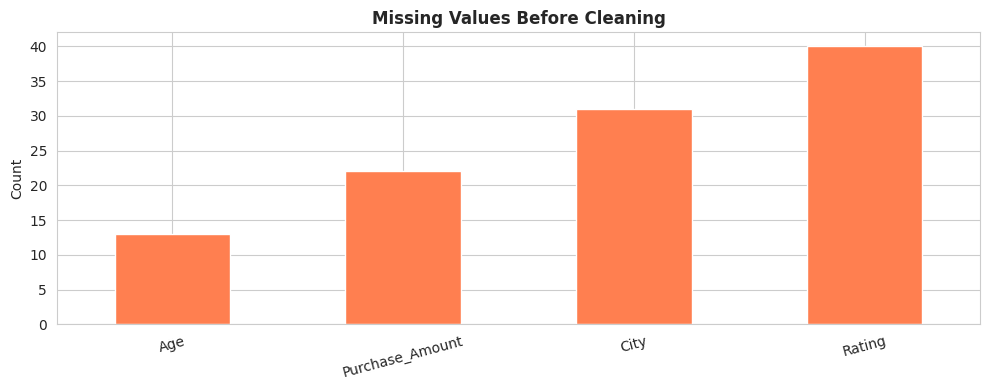

Missing after: 0


In [4]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(10,4))
missing.plot(kind='bar', color='coral')
plt.title('Missing Values Before Cleaning', fontweight='bold')
plt.ylabel('Count'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace=True)
df['Email'].fillna('unknown@email.com', inplace=True)
df['City'].fillna('Unknown', inplace=True)
df['Rating'].fillna(df['Rating'].mode()[0], inplace=True)
print('Missing after:', df.isnull().sum().sum())

## Step 4: Standardize & Fix Data Types

In [5]:
df['City'] = df['City'].str.strip().str.title()
df['Age'] = df['Age'].astype(int)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.loc[~df['Rating'].isin([1,2,3,4,5]),'Rating'] = df['Rating'].mode()[0]
print('Unique cities after fix:', sorted(df['City'].unique()))
print('Data types:')
print(df.dtypes)

Unique cities after fix: ['Bangalore', 'Delhi', 'Mumbai', 'Pune', 'Unknown']
Data types:
CustomerID           int64
Name                object
Age                  int64
Email               object
Purchase_Amount    float64
City                object
Rating             float64
dtype: object


## Step 5: Outlier Detection & Final Summary

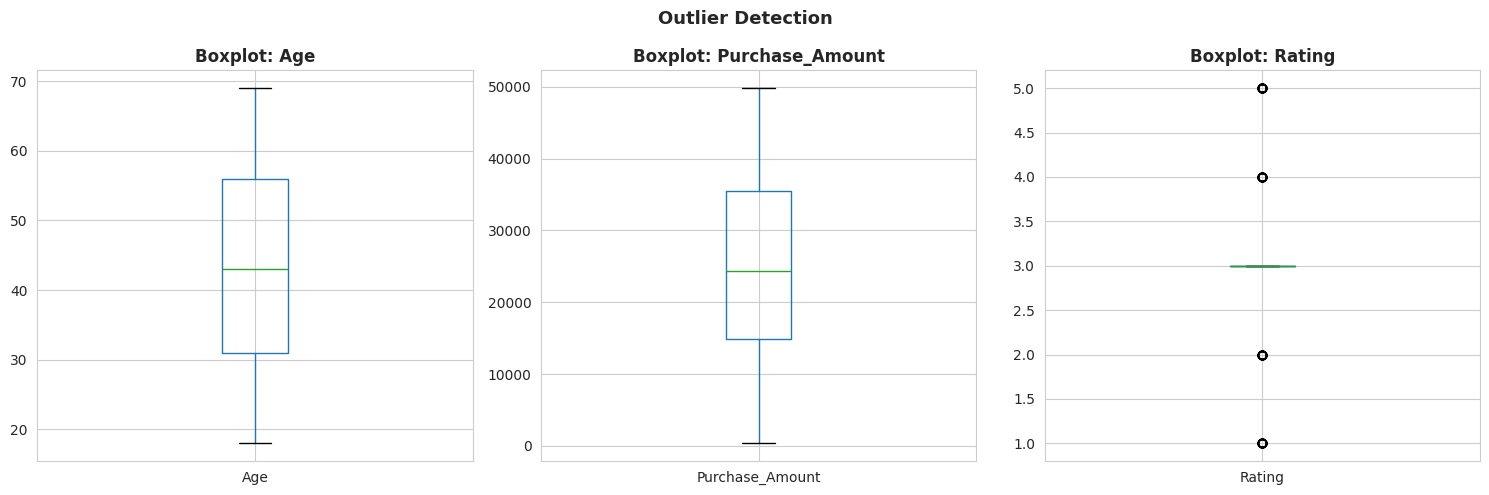

Outliers removed: 0
Final shape: (300, 7)
Saved cleaned_data.csv!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['Age','Purchase_Amount','Rating']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot: {col}', fontweight='bold')
plt.suptitle('Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Q1 = df['Purchase_Amount'].quantile(0.25)
Q3 = df['Purchase_Amount'].quantile(0.75)
IQR = Q3 - Q1
before = len(df)
df = df[(df['Purchase_Amount'] >= Q1-1.5*IQR) & (df['Purchase_Amount'] <= Q3+1.5*IQR)]
print(f'Outliers removed: {before - len(df)}')
print(f'Final shape: {df.shape}')
df.to_csv('cleaned_data.csv', index=False)
print('Saved cleaned_data.csv!')